--- 

# Importing Data and Libraries

In [2]:
import pandas as pd
import numpy as np

#plotting
import matplotlib.pyplot as plt
import seaborn as sns

#geographic plotting
import geopandas as gpd
import geodatasets
from shapely.geometry import Point

In [3]:
data = pd.read_csv("global_bleaching_environmental.csv")
df = data.copy()

C:\Users\zahir\AppData\Local\Temp\ipykernel_6584\2735263438.py:1: DtypeWarning: Columns (13,15,24) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("global_bleaching_environmental.csv")


---
# Data Cleaning

In [4]:
df.head()

,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,...,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.163,-82.5260,Atlantic,nd,Tropical Atlantic,Cuba and Cayman Islands,Cuba,...,5,0,0,0.74,7.25,0.18,2005-09-15,nd,nd,nd
1,3467,10324754,Donner,-17.575,-149.7833,Pacific,nd,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,...,4,0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,nd
2,1794,10323866,Donner,18.369,-64.5640,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,...,7,0,0,1.04,11.66,0.26,2006-01-15,nd,nd,nd
3,8647,10328028,Donner,17.760,-64.5680,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,4,0,0,0.75,5.64,0.2,2006-04-15,nd,nd,nd
4,8648,10328029,Donner,17.769,-64.5830,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,5,0,0,0.92,6.89,0.25,2006-04-15,nd,nd,nd


In [5]:
df.columns

Index(['Site_ID', 'Sample_ID', 'Data_Source', 'Latitude_Degrees',
       'Longitude_Degrees', 'Ocean_Name', 'Reef_ID', 'Realm_Name',
       'Ecoregion_Name', 'Country_Name', 'State_Island_Province_Name',
       'City_Town_Name', 'Site_Name', 'Distance_to_Shore', 'Exposure',
       'Turbidity', 'Cyclone_Frequency', 'Date_Day', 'Date_Month', 'Date_Year',
       'Depth_m', 'Substrate_Name', 'Percent_Cover', 'Bleaching_Level',
       'Percent_Bleaching', 'ClimSST', 'Temperature_Kelvin',
       'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum',
       'Temperature_Kelvin_Standard_Deviation', 'Windspeed', 'SSTA',
       'SSTA_Standard_Deviation', 'SSTA_Mean', 'SSTA_Minimum', 'SSTA_Maximum',
       'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation',
       'SSTA_FrequencyMax', 'SSTA_FrequencyMean', 'SSTA_DHW',
       'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA',
       'TSA_Standard_Deviation', 'TSA_Minimum', 'TSA_Maximum', 'TSA_Mean',
       'TSA_Freq

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41361 entries, 0 to 41360
Data columns (total 62 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Site_ID                                41361 non-null  int64  
 1   Sample_ID                              41361 non-null  int64  
 2   Data_Source                            41361 non-null  object 
 3   Latitude_Degrees                       41361 non-null  float64
 4   Longitude_Degrees                      41361 non-null  float64
 5   Ocean_Name                             41361 non-null  object 
 6   Reef_ID                                41361 non-null  object 
 7   Realm_Name                             41361 non-null  object 
 8   Ecoregion_Name                         41361 non-null  object 
 9   Country_Name                           41361 non-null  object 
 10  State_Island_Province_Name             41361 non-null  object 
 11  Ci

#### Null values in the dataset are represented as object type strings "nd". This results in many quantitative variables being object types which impedes on our ability to analyze them. We must first replace all "nd" with NaN values, and then convert all the known quantitative variables to floats.

In [7]:
print(df[df["Percent_Bleaching"] != "nd"].shape)
df = df.replace("nd", np.nan)

(34515, 62)


In [8]:
df.isna().mean().sort_values(ascending=False).head(10)

Site_Comments         0.945432
Bleaching_Comments    0.935471
Sample_Comments       0.928483
Site_Name             0.832403
Bleaching_Level       0.455260
Substrate_Name        0.306279
Reef_ID               0.303184
Percent_Cover         0.301129
Percent_Bleaching     0.165518
Depth_m               0.043495
dtype: float64

- Notice that after SSTA_minimum, many of the missing value percentages are the same (3.578e-3, 3.191e-3).

- Most environmental variables (SSTA_*, TSA_*, Temperature_*, Windspeed, etc.) have <0.5% missing values.

- You can safely drop or interpolate those few missing rows.

- Location and metadata columns (Country_Name, State_Island_Province_Name, Ecoregion_Name, etc.) are nearly complete.


However, Bleaching_Level being ~45% missing:
* Bleaching data was not recorded in many cases, or
* Some sites only have environmental data (not biological observations).

Need to decide later whether to:
* Focus analysis on rows where Percent_Bleaching are non-null, and experiment with imputation techniques
* Model bleaching as a partially observed target variable

In [9]:
numeric_cols = ['Distance_to_Shore','Depth_m','Percent_Cover','Percent_Bleaching','ClimSST','Temperature_Kelvin','Temperature_Mean','Temperature_Minimum','Temperature_Maximum','Temperature_Kelvin_Standard_Deviation','Windspeed','SSTA','SSTA_Standard_Deviation',
                    'SSTA_Mean','SSTA_Minimum','SSTA_Maximum','SSTA_Frequency','SSTA_Frequency_Standard_Deviation','SSTA_FrequencyMax','SSTA_FrequencyMean','SSTA_DHW','SSTA_DHW_Standard_Deviation','SSTA_DHWMax','SSTA_DHWMean','TSA','TSA_Standard_Deviation',
                    'TSA_Minimum','TSA_Maximum','TSA_Mean','TSA_Frequency','TSA_Frequency_Standard_Deviation','TSA_FrequencyMax','TSA_FrequencyMean','TSA_DHW','TSA_DHW_Standard_Deviation','TSA_DHWMax','TSA_DHWMean']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric) #convert numeric columns to floats

In [10]:
df = df.drop(['Site_Name','Reef_ID','Exposure','City_Town_Name','Bleaching_Level','Site_Comments',
              'Bleaching_Comments','Sample_Comments','Ocean_Name','Sample_ID',"State_Island_Province_Name", "Ecoregion_Name", "Country_Name"], axis = 1)
df['Date'] = pd.to_datetime(df['Date']) 

#### We can drop these columns:
- Site_Name has a mix of names numbers and NaN values which are useless for our analysis
- Substrate_Name contains 'Hard Coral', 'Nutrient Indicator Algae', 'Fleshy Seaweed' and many NaN values
- City_Town_Name is also irrelevant to our analysis especially given our other variables.
- All dropped variables were inspected for unique values, and were deemed useless for exploratory data analysis (EDA), and future modeling

---

# Exploratory Data Analysis (EDA)

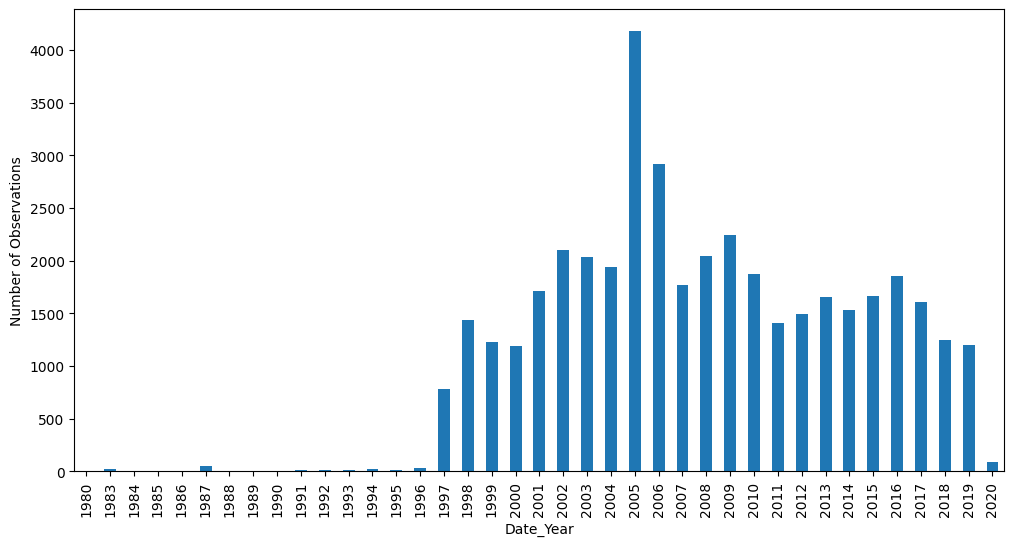

In [11]:
df['Date_Year'].value_counts().sort_index().plot(kind='bar', figsize=(12,6))
plt.ylabel("Number of Observations");

In [12]:
df = df[df.Date_Year > 1996] #drop years before 1996

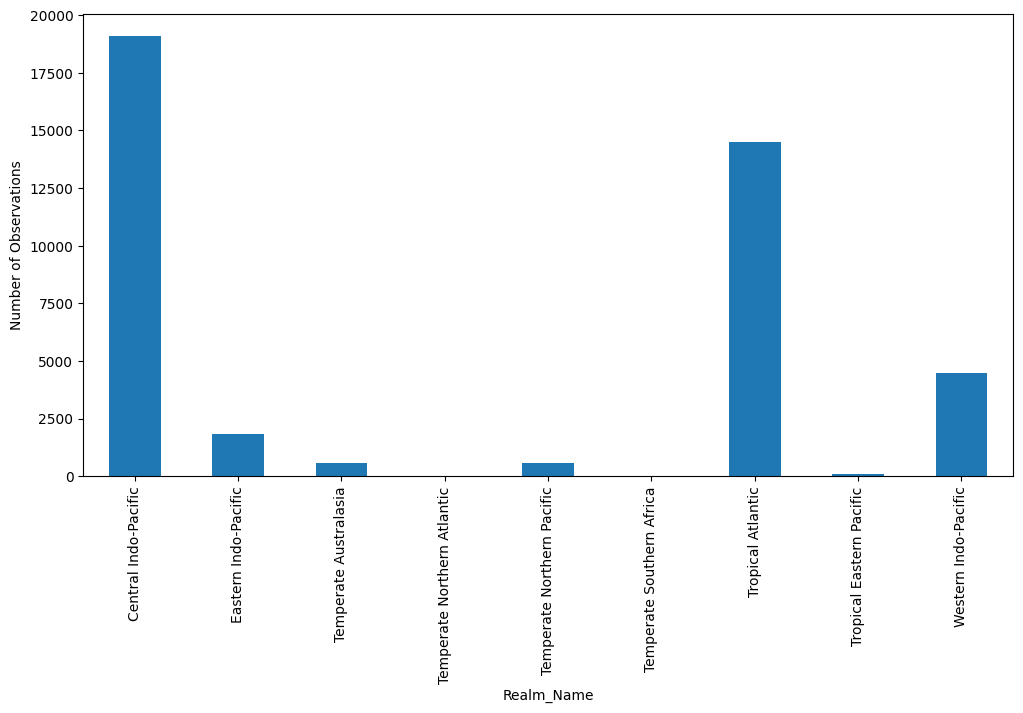

In [13]:
df['Realm_Name'].value_counts().sort_index().plot(kind='bar', figsize=(12,6))
plt.ylabel("Number of Observations");

Text(0.5, 1.0, 'Total Data Correlation Heatmap')

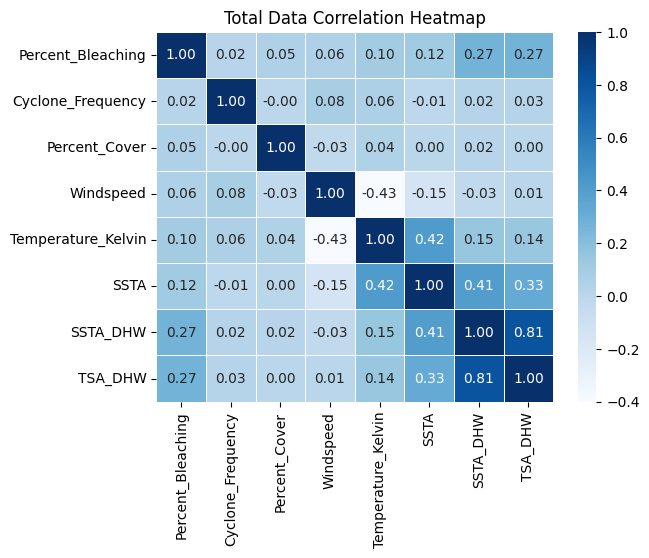

In [14]:
sns.heatmap(df[['Percent_Bleaching','Cyclone_Frequency','Percent_Cover','Windspeed','Temperature_Kelvin','SSTA','SSTA_DHW','TSA_DHW']].corr(),vmin=-0.4,cmap= "Blues", annot=True, fmt=".2f", linewidths=.5);
plt.title("Total Data Correlation Heatmap")

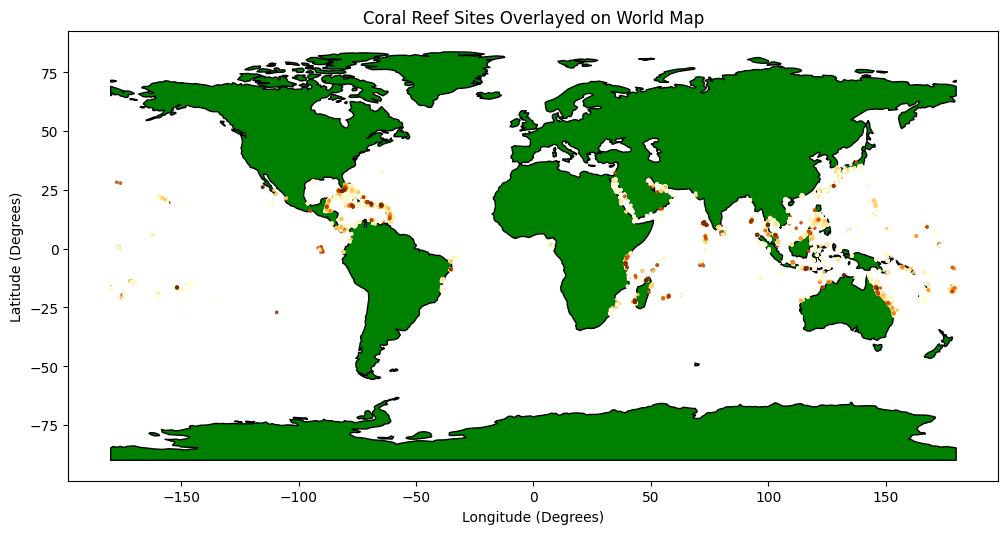

In [15]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['Longitude_Degrees'], df['Latitude_Degrees']),
    crs="EPSG:4326"  #WGS84 (degrees)
)

world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

fig, ax = plt.subplots(figsize=(12, 6))
world.plot(ax=ax, color='green', edgecolor='black')
gdf.plot(ax=ax,column='Percent_Bleaching',cmap = 'YlOrBr',markersize=3,alpha=0.8)
plt.title("Coral Reef Sites Overlayed on World Map")
plt.ylabel("Latitude (Degrees)")
plt.xlabel("Longitude (Degrees)");

### Focusing On Tropical Atlantic Realm 

* Create ta dataframe
* recreate visualizations and correlation matrices
* finalize identification of predictor variables
* more predictor variable exploratory visualizations
* modeling to predict percent bleaching using predictor variables
* report metrics
* visualize metrics
* create presentation and more

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41170 entries, 0 to 41360
Data columns (total 49 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Site_ID                                41170 non-null  int64         
 1   Data_Source                            41170 non-null  object        
 2   Latitude_Degrees                       41170 non-null  float64       
 3   Longitude_Degrees                      41170 non-null  float64       
 4   Realm_Name                             41170 non-null  object        
 5   Distance_to_Shore                      41168 non-null  float64       
 6   Turbidity                              41164 non-null  object        
 7   Cyclone_Frequency                      41170 non-null  float64       
 8   Date_Day                               41170 non-null  int64         
 9   Date_Month                             41170 non-null  int64      

In [17]:
anomolies = df[df["SSTA"] > 0]
print(anomolies.shape, "\n")

print(anomolies.isna().mean().sort_values(ascending=False).head(6))

(25729, 49) 

Substrate_Name       0.315442
Percent_Cover        0.307979
Percent_Bleaching    0.147732
Depth_m              0.052004
SSTA_Minimum         0.000855
Data_Source          0.000000
dtype: float64


In [18]:
ta = df[df["Realm_Name"] == "Tropical Atlantic"]
ta = ta.sort_values('Date')

ta_anomolies = anomolies[anomolies["Realm_Name"] == "Tropical Atlantic"]
ta_anomolies = ta_anomolies.sort_values('Date')

ta.shape, ta_anomolies.shape

((14500, 49), (8990, 49))

Text(0.5, 88.00098062672608, 'Longitude (Degrees)')

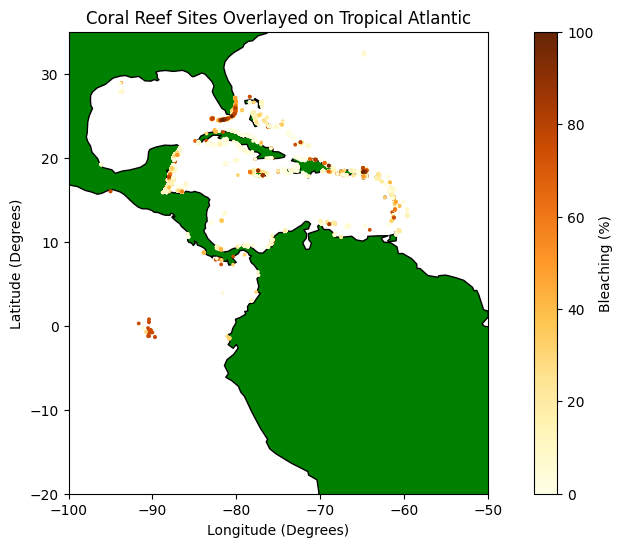

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
world.plot(ax=ax, color='green', edgecolor='black')
gdf.plot(ax=ax,column='Percent_Bleaching',markersize=3,legend=True,legend_kwds={'label': "Bleaching (%)"},cmap='YlOrBr')
plt.title("Coral Reef Sites Overlayed on Tropical Atlantic")
ax.set_xlim([-100, -50])
ax.set_ylim([-20, 35])
plt.ylabel("Latitude (Degrees)")
plt.xlabel("Longitude (Degrees)")

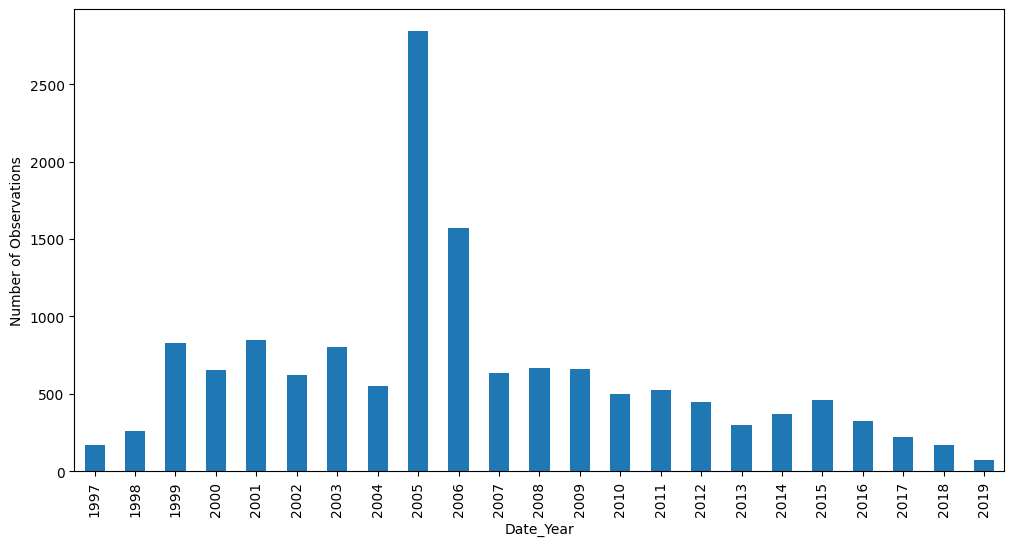

In [20]:
ta['Date_Year'].value_counts().sort_index().plot(kind='bar', figsize=(12,6))
plt.ylabel("Number of Observations");